EVA VWLS method for AMAS Project, based on https://doi.org/10.1016/j.hydroa.2018.100012

original code by peter resch, 12.3.2026

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy import stats
from matplotlib.markers import MarkerStyle
import os

my_cmap = plt.colormaps["turbo"]
my_marker=MarkerStyle(marker="1", fillstyle='full', transform=None, capstyle=None, joinstyle=None)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['savefig.dpi']=600
plt.rcParams["savefig.bbox"]='tight'
plt.rcParams["figure.figsize"]='6,3'
text_style = dict(horizontalalignment='right', verticalalignment='center',
                  fontsize=12, fontfamily='monospace')

r = np.random
r.seed(42)

save_figures = False

## #read in file

In [7]:
print(os.getcwd())
#os.chdir("code/VWLS/")

/home/peter/AMAS_PROJECT/Code


In [11]:
"""dataset location"""
filename="gauss-mu=5,sigma=2.0,N=e9,cutoff=4sig.csv"
directory = "data"
filepath = directory+ "/" + filename
print(f"Filepath: {filepath}")

Filepath: data/gauss-mu=5,sigma=2.0,N=e9,cutoff=4sig.csv


In [12]:
"""read the values from the text file"""
extreme_values_from_file = []
with open(filepath, "r") as f:
    for line in f:
        extreme_values_from_file.append(float(line.strip()))

print(f"Number of extreme values: {len(extreme_values_from_file)}")

Number of extreme values: 33402


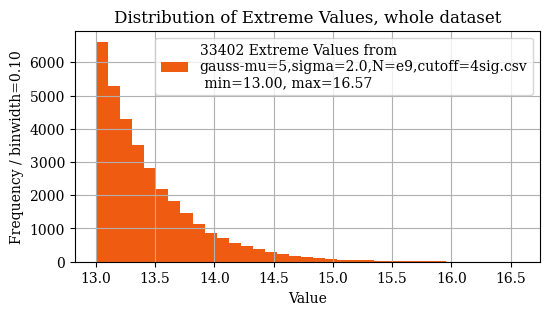

In [13]:
"""illustrating the distribution of the extreme values with a histogram"""
min_value = min(extreme_values_from_file)
max_value = max(extreme_values_from_file)
#n_bins = 50
bin_width = 0.1
n_bins = int((max_value - min_value) / bin_width)

plt.hist(extreme_values_from_file, bins=n_bins, alpha=1, color=my_cmap(0.8),label=f"{len(extreme_values_from_file)} Extreme Values from\n{filename}\n min={min_value:.2f}, max={max_value:.2f}")
plt.xlabel("Value")
plt.ylabel(f"Frequency / binwidth={bin_width:.2f}")
plt.title("Distribution of Extreme Values, whole dataset")
plt.grid()
plt.legend()
plt.show()

if save_figures:
    plt.savefig(f"{directory}/histogram_extreme_values_{filename}.png")

## #Selecting Distribution and estimating start parameters

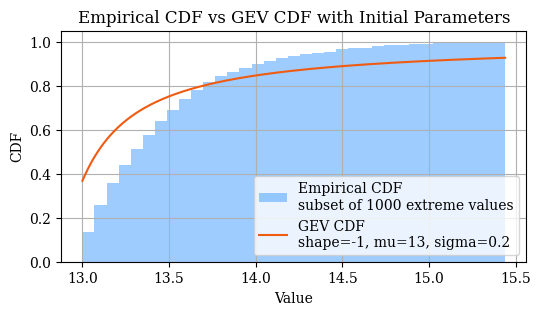

In [51]:
"""define starting parameters for fitting the GEV distribution"""
shape_param = -1
mu_param = 13
sigma_param = 0.2

def gev_cdf(xi_array, shape_param, mu_param, sigma_param):
    return stats.genextreme.cdf(x=xi_array, c=shape_param, loc=mu_param, scale=sigma_param)


"""select a subset of the extreme values for fitting the GEV distribution"""
subset_size = 1000
x_subset=extreme_values_from_file[:subset_size]


"""plotting the empirical CDF of the subset of extreme values and the GEV CDF with the initial parameters"""
xi_values_plot = np.linspace(min(x_subset), max(x_subset), 1000)
gev_cdf_values = gev_cdf(xi_values_plot, shape_param, mu_param, sigma_param)

plt.hist(x_subset, bins=n_bins, density=True, alpha=0.5, color=my_cmap(0.2), label=f"Empirical CDF\nsubset of {subset_size} extreme values",cumulative=True)
plt.plot(xi_values_plot, gev_cdf_values, label=f"GEV CDF\nshape={shape_param}, mu={mu_param}, sigma={sigma_param}", color=my_cmap(0.8))
plt.xlabel("Value")
plt.ylabel("CDF")
plt.title("Empirical CDF vs GEV CDF with Initial Parameters")
plt.grid()
plt.legend()
plt.show()
if save_figures:
    plt.savefig(f"{directory}/empirical_cdf_vs_gev_cdf_initial_{filename}.png")

## #Weibull Plotting Positions

In [75]:
"""Ranking the subset of data points"""
x_m = np.sort(x_subset)
m_array = np.arange(1, subset_size + 1)  # ranks from 1 to subset_size


"""define Weibull plotting positions"""
def weibull_p_m(rank_m, n):
    """ rank_m >= 1
        n = number of data points in the subset"""
    p_m=rank_m / (n + 1)
    #print(f"P(m={rank_m},N={n}) = {p_m:.8f}")
    return p_m


"""best estimate for xi_m in the given search range"""
def first_estimate_xi(rank_m,search_min,search_max):
    """returns  -1 if search_min is too high
                +1 if search_max is too low
                proposed xi_m and stepsize if the search range contains the solution"""

    p_m=weibull_p_m(rank_m, subset_size)
    f_min = gev_cdf(search_min, shape_param, mu_param, sigma_param)
    f_max = gev_cdf(search_max, shape_param, mu_param, sigma_param)
    #print(f_max)
    if f_min > p_m:
        #print(f"GEV CDF at search_min={search_min:.4f} is {f_min}: greater than p_m={p_m:.6f} for rank {rank_m}. Consider decreasing search_min.")
        return -1
    elif f_max < p_m:
        #print(f"GEV CDF at search_max={search_max:.4f} is {f_max}: less than p_m={p_m:.6f} for rank {rank_m}. Consider increasing search_max.")
        return +1
    
    else:
        diff = (search_max - search_min)
        if diff <= 0:
            print(f"rank_m={rank_m}: diff={diff}")
            raise ValueError("search_max must be greater than search_min.")
        
        steps=100
        stepsize = diff / steps
        xi_proposal = np.arange(search_min, search_max, stepsize)

        for m in range(steps):
            gev_cdf_value = gev_cdf(xi_proposal[m], shape_param, mu_param, sigma_param)
            #print(f"xi_proposal: {xi_proposal[m]:.4f}, GEV CDF: {gev_cdf_value:.6f}, p_m: {p_m:.6f}")
            if gev_cdf_value >= p_m:
                #print(f"Found corresponding xi_m in the proposal array")
                return xi_proposal[m],stepsize
        return search_max,stepsize# between last proposal and search_max, the solution must lie



"""best estimate for xi_m in the search range with a given resolution of decimal places """
def best_estimate_xi_with_resolution(rank_m,search_min,search_max,resolution=0.01):
    while True:
        result = first_estimate_xi(rank_m, search_min, search_max)
        #print(f"in best_estimate loop: first_estimate result={result}")
        if result == -1:
            # shift range downward
            range = search_max - search_min
            search_min -= range
            search_max -= range
            continue

        if result == 1:
            # shift range upward
            range = search_max - search_min
            search_min += range
            search_max += range
            continue

        # Here result is guaranteed to be a tuple (xi_propose, step_size)
        xi_propose, step_size = result

        if step_size <= resolution:
            return xi_propose

        # refine around candidate
        search_max = xi_propose
        search_min = xi_propose - step_size

In [76]:

#testing
rank_m =329
result = first_estimate_xi(rank_m, 0, 13)
if result is None:
    raise ValueError(
        f"best_estimate_xi returned None for rank_m={rank_m} in range [{x_m[0]:.4f}, {x_m[-1]:.4f}]"
    )
xi_value, xi_in_range = result

print(f"cdf(m={rank_m}) = {gev_cdf(xi_value, shape_param, mu_param, sigma_param):.8f}")
print(f"xi(m={rank_m}) = {xi_value:.4f}")
print(f"P(m={rank_m},N={subset_size}) = {weibull_p_m(rank_m, subset_size):.8f}")
print(f"x(m={rank_m}) = {x_m[rank_m]:.4f}")
print(f"Difference between GEV CDF at xi_m and Weibull plotting position: {gev_cdf(xi_value, shape_param, mu_param, sigma_param) - weibull_p_m(rank_m, subset_size):.8f}")

cdf(m=329) = 0.36787944
xi(m=329) = 13.0000
P(m=329,N=1000) = 0.32867133
x(m=329) = 13.1855
Difference between GEV CDF at xi_m and Weibull plotting position: 0.03920811


In [ ]:
best_estimate_xi_with_resolution(rank_m, 13, 14, resolution=0.000001)

np.float64(12.979743999999924)

In [103]:
def round_partial(value, resolution):
    return np.round(value / resolution) * resolution


def find_all_xi_m(ranked_m,estimate_search_min,estimate_search_max,res=0.0001):
    xi_m=np.zeros_like(ranked_m, dtype=float)
    for i,rank in enumerate(ranked_m):#rank in [1, subset_size]
        #print(f"in find_all_xi_m: rank{rank}")
        if i==0:
            xi_m[0] = round_partial(best_estimate_xi_with_resolution(1, estimate_search_min, estimate_search_max,res),res)
            continue
        estimate=best_estimate_xi_with_resolution(rank, xi_m[i-1], xi_m[i-1]+2,res)
        xi_m[i] = round_partial(estimate,res)

        print(f"Calculated xi_m for rank {rank}/{subset_size}", end="\r")
    
    xi_m = np.array(xi_m)
    return xi_m

In [105]:
"""calculating plotting positions and corresponding xi_m for the ranked data points"""
ranks_m = np.arange(1, subset_size + 1)
p_m = weibull_p_m(ranks_m, n=subset_size)

xi_m = find_all_xi_m(ranks_m,10,15,0.001)

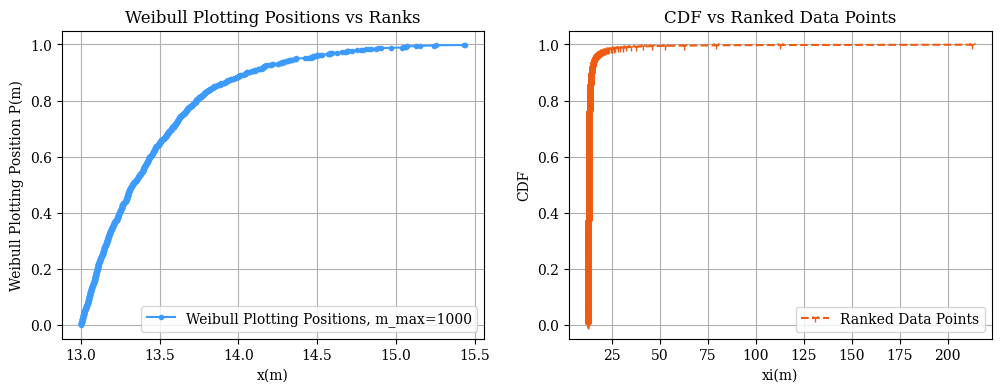

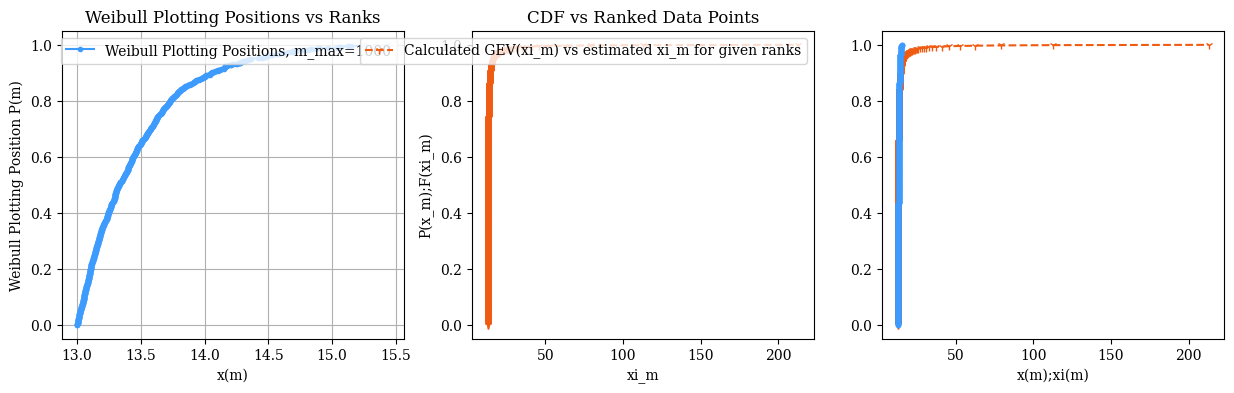

In [ ]:
"""Illustrating the ranked data points and their Weibull plotting positions"""
fig,[ax_weibull,ax_cdf,ax_combi]=plt.subplots(1,3,figsize=(15,4))

ax_weibull.plot(x_m, p_m, color=my_cmap(0.2), label=f"Weibull Plotting Positions, m_max={subset_size}", marker='.', linestyle='-')
ax_weibull.set_xlabel("x(m)")
ax_weibull.set_ylabel("Weibull Plotting Position P(m)")
ax_weibull.set_title("Weibull Plotting Positions vs Ranks")
ax_weibull.grid()
ax_weibull.legend()


ax_cdf.plot(xi_m,gev_cdf(xi_m,shape_param,mu_param,sigma_param), color=my_cmap(0.8), label="Calculated GEV(xi_m) vs estimated xi_m for given ranks", marker=my_marker, linestyle='--')
ax_cdf.set_xlabel("xi_m")
ax_cdf.set_ylabel("GEV CDF=F(xi_m)")
ax_cdf.set_title("Calculated GEV(xi_m) vs estimated xi_m for given ranks")
ax_cdf.grid()
ax_cdf.legend()

ax_combi.plot(xi_m,gev_cdf(xi_m,shape_param,mu_param,sigma_param), color=my_cmap(0.8), label="GEV CDF(xi_m)", marker=my_marker, linestyle='--')
ax_combi.plot(x_m, p_m, color=my_cmap(0.2), label=f"P(x_m)", marker='.', linestyle='-')
ax_combi.set_xlabel("x(m);xi(m)")
ax_combi.set_ylabel("P(x_m);F(xi_m)")
ax_combi.set_title("CDF vs Ranked Data Points")
ax_combi.grid()
ax_combi.legend()

if save_figures
    #fig.save

## #Weighing and fitting - functions

## #Reject data - function

## #Fitting process